# Congressional Trade Analysis
This notebook analyzes congressional trades, their features, and their subsequent stock returns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set_theme(style="whitegrid")

print("success")

success


## 1. Data Loading


In [2]:
# Load datasets
trades_features = pd.read_csv('../data/trades_with_features.csv')
trades_returns = pd.read_csv('../data/trades_with_returns.csv')

# Convert dates
for df in [trades_features, trades_returns]:
    df['traded_date'] = pd.to_datetime(df['traded_date'])
    df['published_date'] = pd.to_datetime(df['published_date'])

print(f"Trades with features: {len(trades_features)}")
print(f"Trades with returns: {len(trades_returns)}")


Trades with features: 7303
Trades with returns: 9675


## 2. Feature Analysis
Analyzing the characteristics of the trades and the members of congress making them.


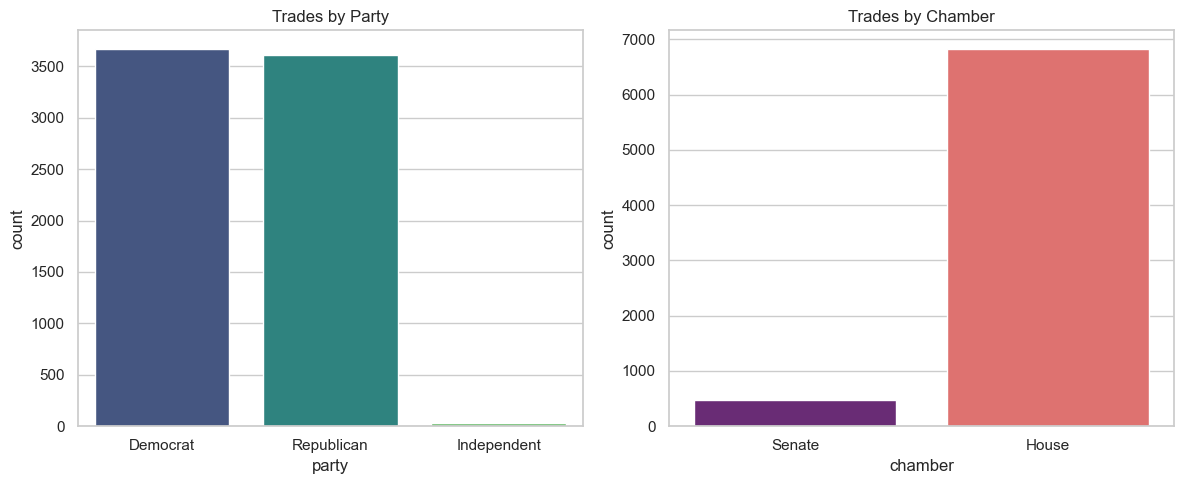

In [3]:
# 1. Trades by Party and Chamber
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=trades_features, x='party', hue='party', palette='viridis', legend=False)
plt.title('Trades by Party')

plt.subplot(1, 2, 2)
sns.countplot(data=trades_features, x='chamber', hue='chamber', palette='magma', legend=False)
plt.title('Trades by Chamber')

plt.tight_layout()
plt.show()


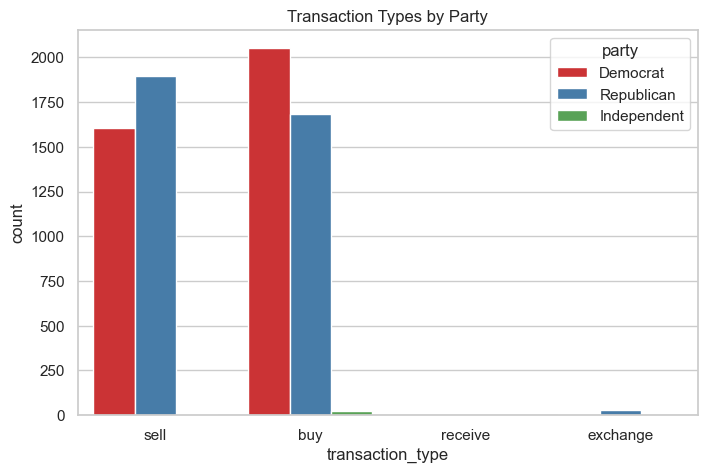

In [4]:
# 2. Transaction Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=trades_features, x='transaction_type', hue='party', palette='Set1')
plt.title('Transaction Types by Party')
plt.show()


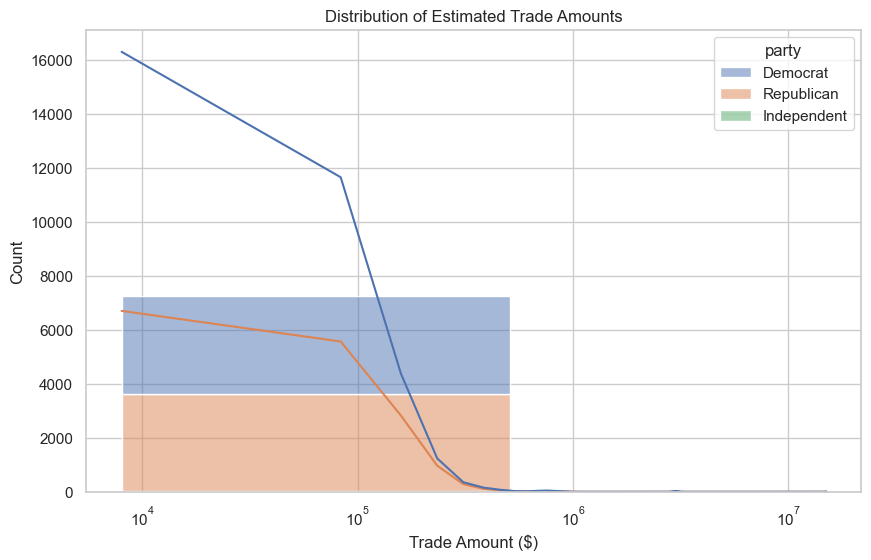

In [5]:
# 3. Trade Amounts (Midpoints)
plt.figure(figsize=(10, 6))
sns.histplot(data=trades_features, x='trade_amount', bins=30, kde=True, hue='party', multiple="stack")
plt.title('Distribution of Estimated Trade Amounts')
plt.xlabel('Trade Amount ($)')
plt.xscale('log')
plt.show()


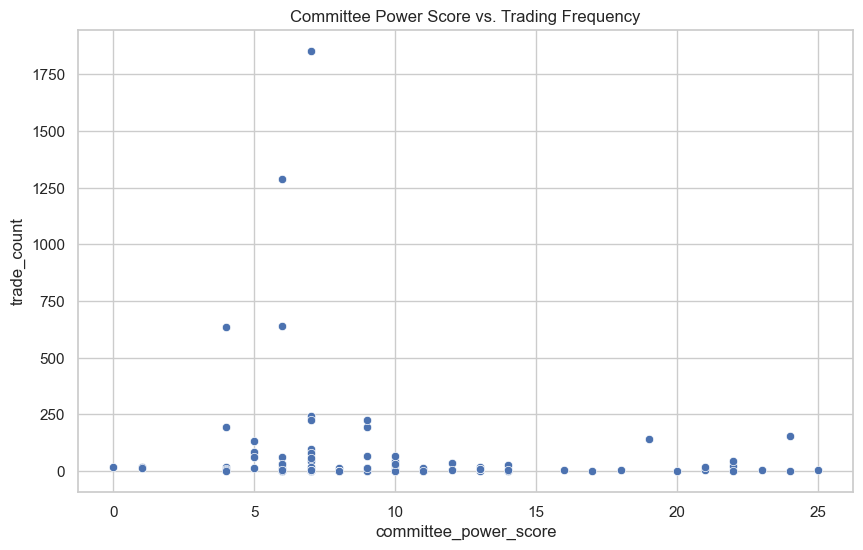

In [6]:
# 4. Committee Power vs. Trading Frequency
member_trades = trades_features.groupby('full_name').agg({
    'committee_power_score': 'first',
    'ticker': 'count'
}).rename(columns={'ticker': 'trade_count'})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=member_trades, x='committee_power_score', y='trade_count')
plt.title('Committee Power Score vs. Trading Frequency')
plt.show()


## 3. Return Analysis
Analyzing how trades performed relative to the market. 


Trades with valid 30-day returns: 9496


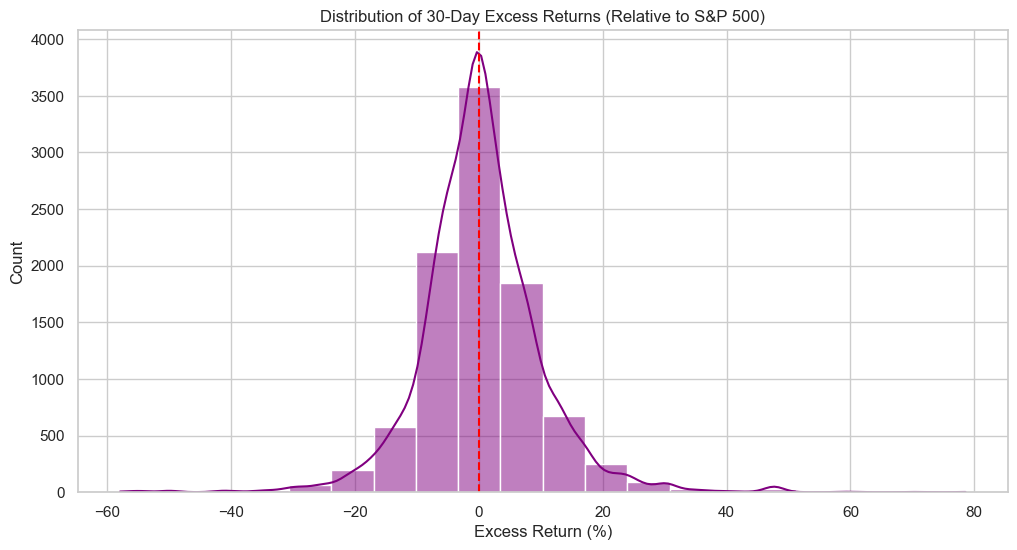

In [7]:
# Filter for trades that have return data
valid_returns = trades_returns.dropna(subset=['return_30d', 'excess_return_30d'])
print(f"Trades with valid 30-day returns: {len(valid_returns)}")

if len(valid_returns) > 0:
    # 1. Distribution of Excess Returns
    plt.figure(figsize=(12, 6))
    sns.histplot(valid_returns['excess_return_30d'], bins=20, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Distribution of 30-Day Excess Returns (Relative to S&P 500)')
    plt.xlabel('Excess Return (%)')
    plt.show()
else:
    print("Not enough data for return distributions yet.")


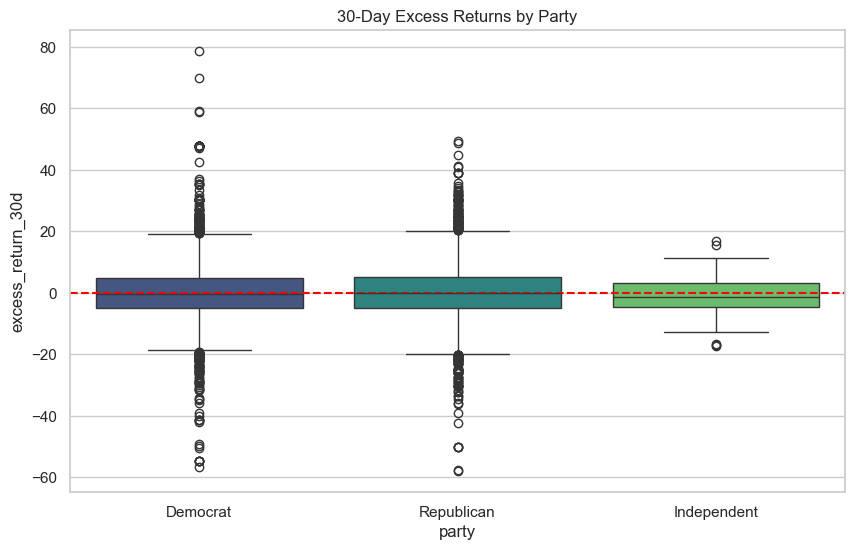

In [8]:
if len(valid_returns) > 0:
    # 2. Performance by Party
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=valid_returns, x='party', y='excess_return_30d', hue='party', palette='viridis', legend=False)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('30-Day Excess Returns by Party')
    plt.show()
else:
    print("Not enough data for party performance analysis yet.")


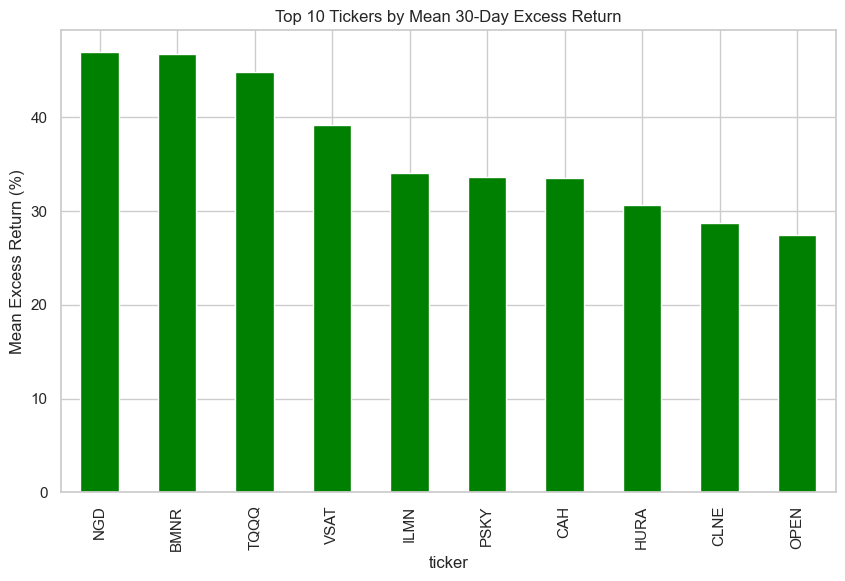

In [9]:
if len(valid_returns) > 0:
    # 3. Top Outperforming Tickers
    top_tickers = valid_returns.groupby('ticker')['excess_return_30d'].mean().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    top_tickers.plot(kind='bar', color='green')
    plt.title('Top 10 Tickers by Mean 30-Day Excess Return')
    plt.ylabel('Mean Excess Return (%)')
    plt.show()
else:
    print("Not enough data for ticker performance analysis yet.")


## 4. Key Findings
- **Feature Analysis**: 
    - **Party Balance**: Trading activity is nearly evenly split between Democrats (3,666 trades) and Republicans (3,611 trades).
    - **Chamber Activity**: The House of Representatives is significantly more active than the Senate, accounting for over 93% of the recorded trades (6,822 vs. 481).
    - **Trade Types**: "Buy" transactions (3,759) slightly outnumber "Sell" transactions (3,503).
    - **Trade Sizes**: Most trades are small, with a median estimated amount of $8,000, though some transactions reach up to $15 million.
    - **Committee Power**: There is a weak negative correlation (-0.14) between a member's committee power score and their trading frequency, suggesting that more powerful members do not necessarily trade more often.

- **Return Analysis**:
    - **Market Performance**: On average, congressional trades show a slight 30-day mean excess return of +0.34% relative to the S&P 500. However, the median excess return is slightly negative (-0.09%), and only 49.2% of trades actually outperform the market.
    - **Party Performance**: Republicans show a slightly higher mean 30-day excess return (+0.35%) and median (0.00%) compared to Democrats (+0.345% mean, -0.24% median) in this dataset.
    - **Outliers**: Significant volatility exists in individual trade performance, with returns ranging from -58% to +79% over a 30-day period.
